##Step 05 - Latency Benchmark & Visualisation

In [ ]:
summary = pd.DataFrame({
    "Vector DB":   ["FAISS (in-memory)", "Pinecone Serverless", "Azure AI Search (Hybrid)"],
    "p50 (ms)":    [round(faiss_p50, 1), round(pinecone_p50, 1), round(azure_p50, 1)],
    "p95 (ms)":    [round(faiss_p95, 1), round(pinecone_p95, 1), round(azure_p95, 1)],
    "Search Type": ["Exact k-NN (L2)", "Approx cosine (ANN)", "BM25 + Vector (RRF)"],
    "Infra":       ["In-process", "Serverless cloud", "Managed Azure cloud"],
    "Cost":        ["Free", "$$", "$$$"],
})
print("=" * 76)
print("LATENCY BENCHMARK -- 20 queries, embedding time included")
print("=" * 76)
print(summary.to_string(index=False))
print("=" * 76)

LATENCY BENCHMARK -- 20 queries, embedding time included
               Vector DB  p50 (ms)  p95 (ms)         Search Type               Infra Cost
       FAISS (in-memory)      26.9      93.9     Exact k-NN (L2)          In-process Free
     Pinecone Serverless      53.9     213.3 Approx cosine (ANN)    Serverless cloud   $$
Azure AI Search (Hybrid)     148.2     221.5 BM25 + Vector (RRF) Managed Azure cloud  $$$


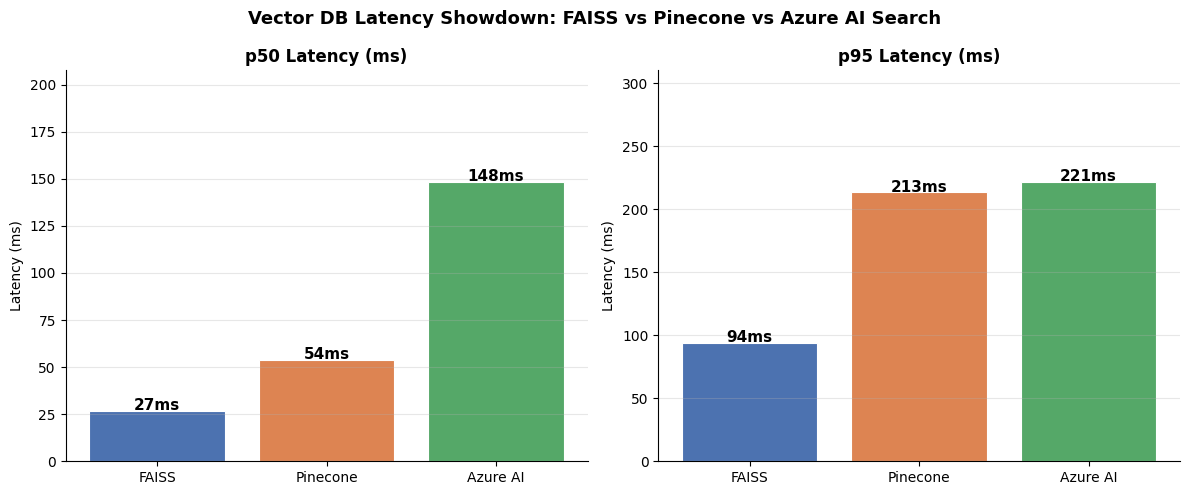

Saved latency_bar.png


In [ ]:
dbs    = ["FAISS", "Pinecone", "Azure AI"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
p50s   = [faiss_p50, pinecone_p50, azure_p50]
p95s   = [faiss_p95, pinecone_p95, azure_p95]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Vector DB Latency Showdown: FAISS vs Pinecone vs Azure AI Search",
             fontsize=13, fontweight="bold")

for ax, vals, label in [(ax1, p50s, "p50 Latency (ms)"), (ax2, p95s, "p95 Latency (ms)")]:
    bars = ax.bar(dbs, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Latency (ms)")
    ax.set_ylim(0, max(vals) * 1.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f"{v:.0f}ms", ha="center", fontweight="bold", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("latency_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved latency_bar.png")

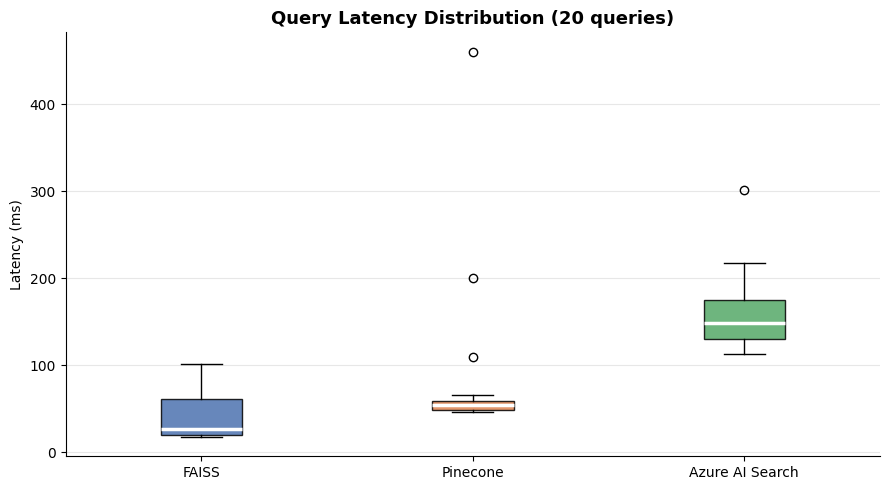

Saved latency_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [faiss_latencies, pinecone_latencies, azure_latencies],
    tick_labels=["FAISS", "Pinecone", "Azure AI Search"],
    patch_artist=True,
    notch=False,
    medianprops=dict(color="white", linewidth=2.5),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("Query Latency Distribution (20 queries)", fontweight="bold", fontsize=13)
ax.set_ylabel("Latency (ms)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved latency_distribution.png")